In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os.path as osp

RESULTS_DIR = osp.join('../', 'results')

py_results = pd.read_csv(osp.join(RESULTS_DIR, 'bench_io_py.csv'))
cpp_results = pd.read_csv(osp.join(RESULTS_DIR, 'bench_io_cpp.csv'))
rust_results = pd.read_csv(osp.join(RESULTS_DIR, 'bench_io_rust.csv'))

In [113]:
py_results

,host,function,duration_formatted(us),M,N
0,zaddle-Ubuntu-Satus,test_encode_1cNxN,36.6613,NaN,128
1,zaddle-Ubuntu-Satus,test_encode_1cNxN,67.2180,NaN,256
2,zaddle-Ubuntu-Satus,test_encode_1cNxN,165.8910,NaN,512
3,zaddle-Ubuntu-Satus,test_encode_1cNxN,536.4820,NaN,1024
4,zaddle-Ubuntu-Satus,test_encode_1cNxN,2186.2310,NaN,2048
5,zaddle-Ubuntu-Satus,test_encode_1cNxN,8007.3857,NaN,4096
6,zaddle-Ubuntu-Satus,test_encode_1cNxN,31137.5857,NaN,8192
7,zaddle-Ubuntu-Satus,test_decode_1cNxN,11.9398,NaN,128
8,zaddle-Ubuntu-Satus,test_decode_1cNxN,30.2964,NaN,256
9,zaddle-Ubuntu-Satus,test_decode_1cNxN,106.1074,NaN,512


In [114]:
cpp_results

,name,iterations,real_time,cpu_time,time_unit,bytes_per_second,items_per_second,label,error_occurred,error_message
0,encode_1cNxN/128,6165,0.237950,0.106559,ms,NaN,NaN,NaN,NaN,NaN
1,encode_1cNxN/256,2369,0.758894,0.384887,ms,NaN,NaN,NaN,NaN,NaN
2,encode_1cNxN/512,498,1.550790,1.405330,ms,NaN,NaN,NaN,NaN,NaN
3,encode_1cNxN/1024,129,5.585030,5.411690,ms,NaN,NaN,NaN,NaN,NaN
4,encode_1cNxN/2048,48,16.868500,16.300100,ms,NaN,NaN,NaN,NaN,NaN
5,encode_1cNxN/4096,14,53.188400,52.592000,ms,NaN,NaN,NaN,NaN,NaN
6,encode_1cNxN/8192,4,216.542000,196.351000,ms,NaN,NaN,NaN,NaN,NaN
7,decode_1cNxN/128,14547,0.047999,0.047998,ms,NaN,NaN,NaN,NaN,NaN
8,decode_1cNxN/256,3835,0.184079,0.184075,ms,NaN,NaN,NaN,NaN,NaN
9,decode_1cNxN/512,952,0.739492,0.739460,ms,NaN,NaN,NaN,NaN,NaN


In [115]:
rust_results

,host,function,duration_formatted(us),M,N
0,zaddle-Ubuntu-Satus,test_encode_1cNxN,29.0560,NaN,128
1,zaddle-Ubuntu-Satus,test_encode_1cNxN,61.7800,NaN,256
2,zaddle-Ubuntu-Satus,test_encode_1cNxN,187.4200,NaN,512
3,zaddle-Ubuntu-Satus,test_encode_1cNxN,653.4900,NaN,1024
4,zaddle-Ubuntu-Satus,test_encode_1cNxN,2464.4000,NaN,2048
5,zaddle-Ubuntu-Satus,test_encode_1cNxN,9260.2000,NaN,4096
6,zaddle-Ubuntu-Satus,test_encode_1cNxN,43402.0000,NaN,8192
7,zaddle-Ubuntu-Satus,test_decode_1cNxN,18.6600,NaN,128
8,zaddle-Ubuntu-Satus,test_decode_1cNxN,67.4050,NaN,256
9,zaddle-Ubuntu-Satus,test_decode_1cNxN,256.2900,NaN,512


In [116]:
# color defines
BLUE = '#1f77b4'
ORANGE = '#ff7f0e'
GREEN = '#2ca02c'
RED = '#d62728'
NAVY = '#9467bd'
YELLOW = '#8c564b'
BLACK = '#000000'

In [117]:
encodeNxN = {}
encodeNxN['py'] = py_results[:7]['duration_formatted(us)'].values
encodeNxN['cpp'] = cpp_results[:7]['real_time'].values * 1e3 # Convert ms to us
encodeNxN['rust'] = rust_results[:7]['duration_formatted(us)'].values

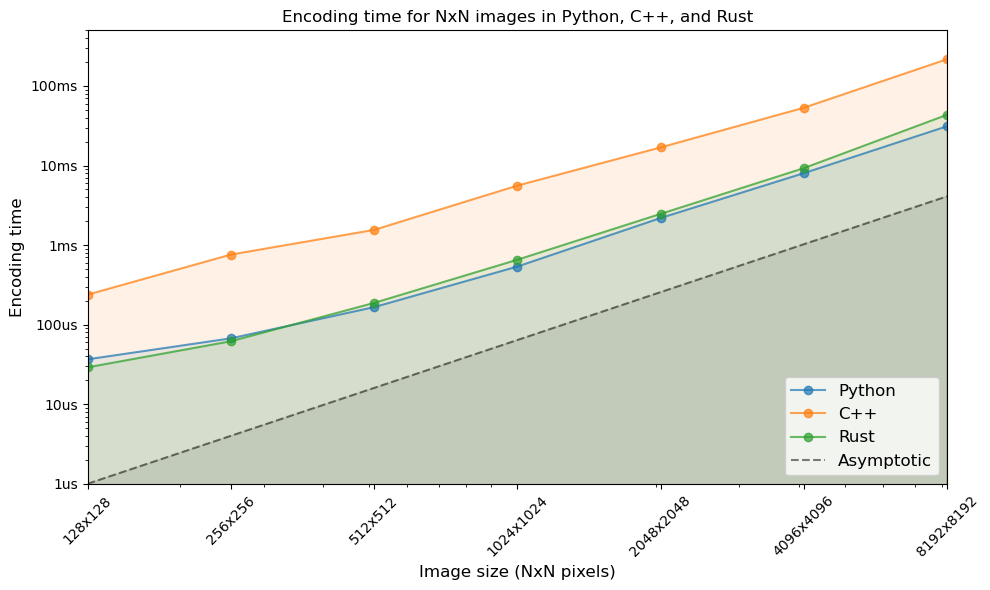

In [118]:
X = np.array([128, 256, 512, 1024, 2048, 4096, 8192], dtype=np.int32)
asymptotic = np.array([1, 4, 16, 64, 256, 1024, 4096], dtype=np.int32)

# plot three
plt.figure(figsize=(10, 6))
plt.plot(X, encodeNxN['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, encodeNxN['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, encodeNxN['rust'], label='Rust', marker='o', alpha=0.7)

plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['rust'], color=GREEN, alpha=0.1)
plt.ylim(1, 500000)
plt.xlim(128, 8192)

plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x}x{x}' for x in X], rotation=45)
plt.yticks([1, 10, 100, 1000, 10000, 100000],
           labels=['1us', '10us', '100us', '1ms', '10ms', '100ms'])
plt.xlabel('Image size (NxN pixels)', fontsize=12)
plt.ylabel('Encoding time', fontsize=12)
plt.title('Encoding time for NxN images in Python, C++, and Rust', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encodeNxN.png'), dpi=300)
# Show the plot
plt.show()

In [119]:
decodeNxN = {}
decodeNxN['py'] = py_results[7:14]['duration_formatted(us)'].values
decodeNxN['cpp'] = cpp_results[7:14]['real_time'].values * 1e3  # Convert ms to us
decodeNxN['rust'] = rust_results[7:14]['duration_formatted(us)'].values

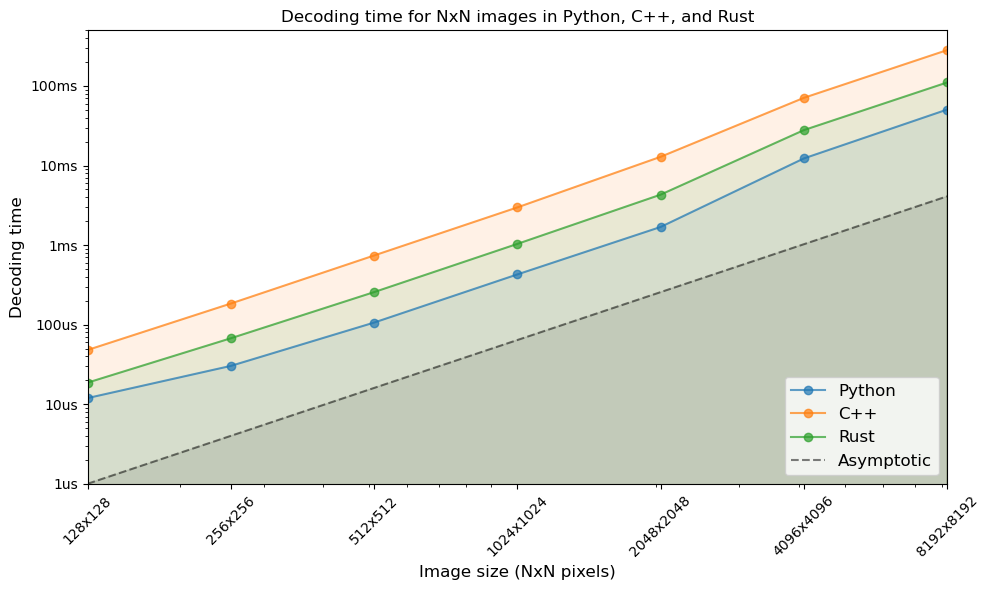

In [120]:
# plot three
plt.figure(figsize=(10, 6))
plt.plot(X, decodeNxN['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, decodeNxN['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, decodeNxN['rust'], label='Rust', marker='o', alpha=0.7)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['rust'], color=GREEN, alpha=0.1)
plt.ylim(1, 500000)
plt.xlim(128, 8192)
plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x}x{x}' for x in X], rotation=45)
plt.yticks([1, 10, 100, 1000, 10000, 100000],
           labels=['1us', '10us', '100us', '1ms', '10ms', '100ms'])
plt.xlabel('Image size (NxN pixels)', fontsize=12)
plt.ylabel('Decoding time', fontsize=12)
plt.title('Decoding time for NxN images in Python, C++, and Rust', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_decodeNxN.png'), dpi=300)

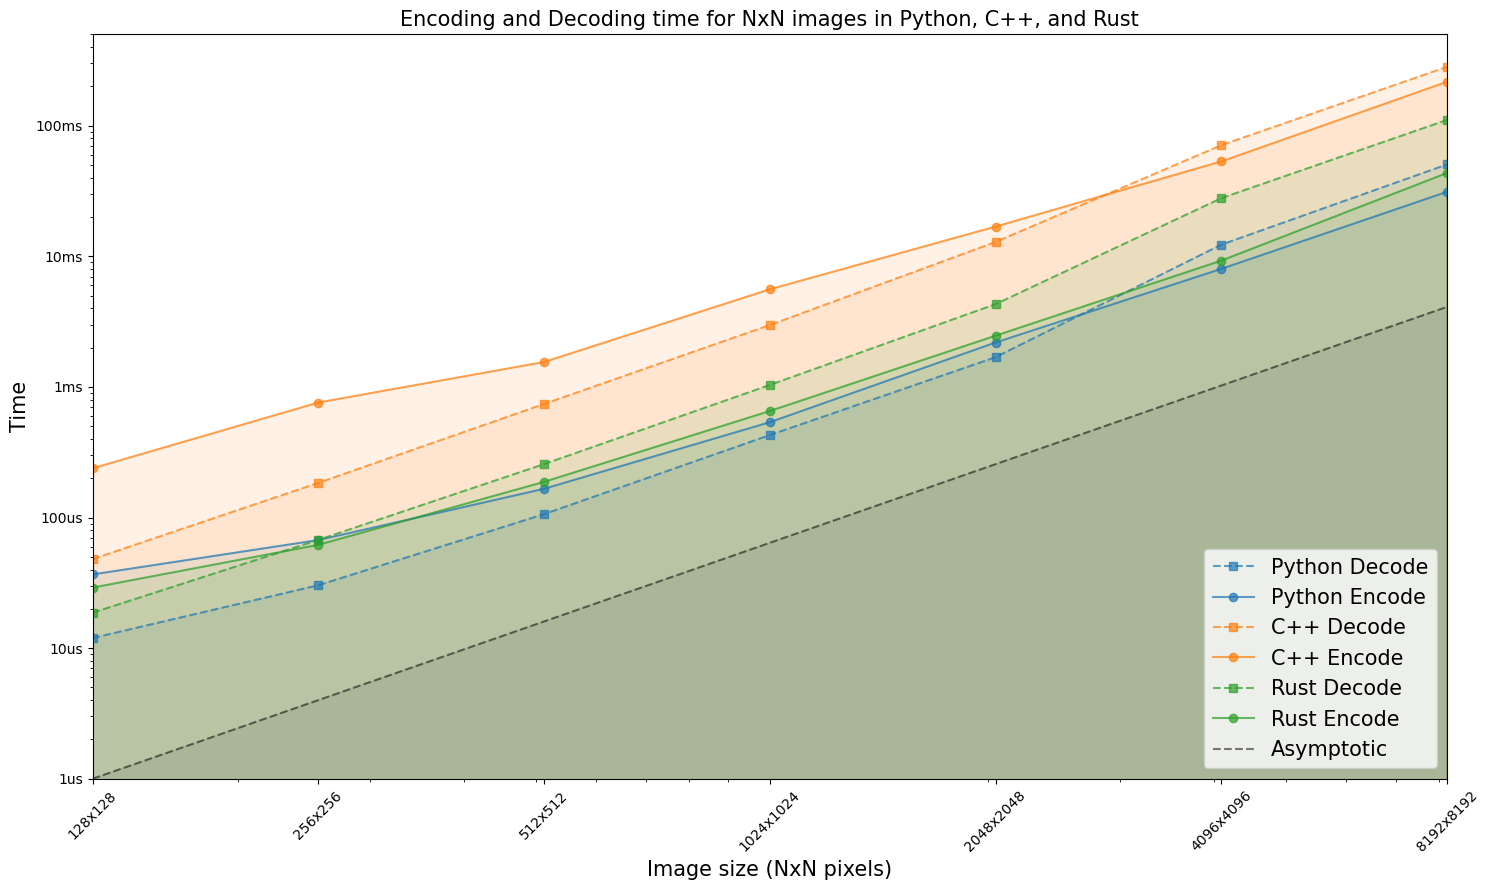

In [121]:
# compare decode & encode
# decode use square marker, encode use circle marker
plt.figure(figsize=(15, 9))
plt.plot(X, decodeNxN['py'], label='Python Decode', marker='s', alpha=0.7, color=BLUE, linestyle='--')
plt.plot(X, encodeNxN['py'], label='Python Encode', marker='o', alpha=0.7, color=BLUE)
plt.plot(X, decodeNxN['cpp'], label='C++ Decode', marker='s', alpha=0.7, color=ORANGE, linestyle='--')
plt.plot(X, encodeNxN['cpp'], label='C++ Encode', marker='o', alpha=0.7, color=ORANGE)
plt.plot(X, decodeNxN['rust'], label='Rust Decode', marker='s', alpha=0.7, color=GREEN, linestyle='--')
plt.plot(X, encodeNxN['rust'], label='Rust Encode', marker='o', alpha=0.7, color=GREEN)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNxN['rust'], color=GREEN, alpha=0.1)
plt.fill_between(X, 0, encodeNxN['rust'], color=GREEN, alpha=0.1)
plt.ylim(1, 500000)
plt.xlim(128, 8192)
plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x}x{x}' for x in X], rotation=45)
plt.yticks([1, 10, 100, 1000, 10000, 100000],
           labels=['1us', '10us', '100us', '1ms', '10ms', '100ms'])
plt.xlabel('Image size (NxN pixels)', fontsize=15)
plt.ylabel('Time', fontsize=15)
plt.title('Encoding and Decoding time for NxN images in Python, C++, and Rust', fontsize=15)
plt.legend(loc='lower right', fontsize=15)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encode_decodeNxN.png'), dpi=300)
# Show the plot
plt.show()

In [122]:
encodeNc = {}
encodeNc['py'] = py_results[14:17]['duration_formatted(us)'].values
encodeNc['cpp'] = cpp_results[14:17]['real_time'].values * 1e3  # Convert ms to us
encodeNc['rust'] = rust_results[14:17]['duration_formatted(us)'].values

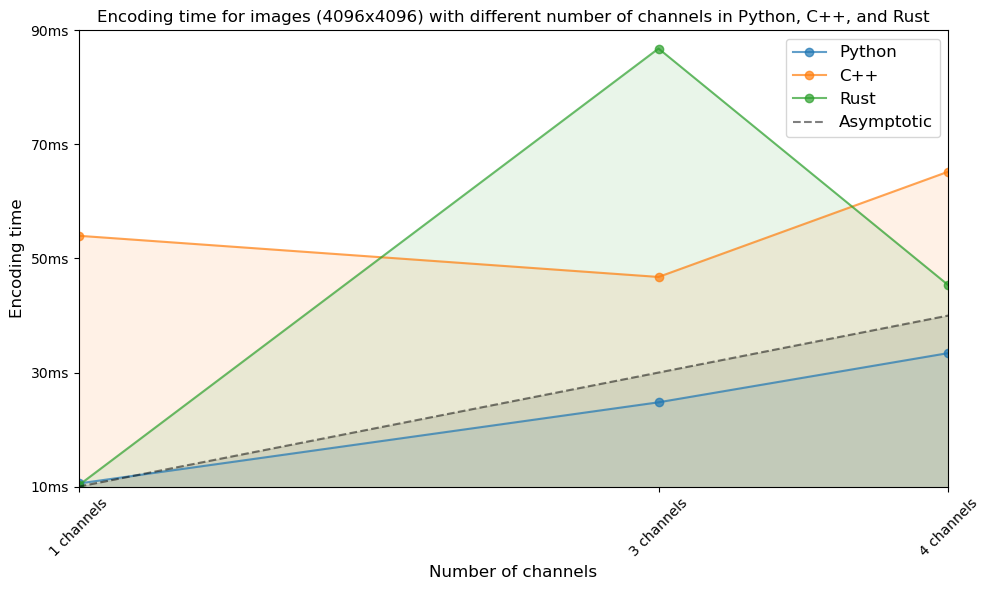

In [123]:
X = np.array([1, 3, 4], dtype=np.int32)
asymptotic = np.array([10000, 30000, 40000], dtype=np.int32)

# plot three
plt.figure(figsize=(10, 6))
plt.plot(X, encodeNc['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, encodeNc['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, encodeNc['rust'], label='Rust', marker='o', alpha=0.7)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, encodeNc['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNc['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNc['rust'], color=GREEN, alpha=0.1)

plt.ylim(10000, 90000)
plt.xlim(1, 4)
plt.xscale('linear')
plt.yscale('linear')
plt.xticks(X, labels=[f'{x} channels' for x in X], rotation=45)
plt.yticks([10000, 30000, 50000, 70000, 90000],
           labels=['10ms', '30ms', '50ms', '70ms', '90ms'])
plt.xlabel('Number of channels', fontsize=12)
plt.ylabel('Encoding time', fontsize=12)
plt.title('Encoding time for images (4096x4096) with different number of channels in Python, C++, and Rust', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encodeNc.png'), dpi=300)

plt.show()

In [124]:
decodeNc = {}
decodeNc['py'] = py_results[17:20]['duration_formatted(us)'].values
decodeNc['cpp'] = cpp_results[17:20]['real_time'].values * 1e3  # Convert ms to us
decodeNc['rust'] = rust_results[17:20]['duration_formatted(us)'].values

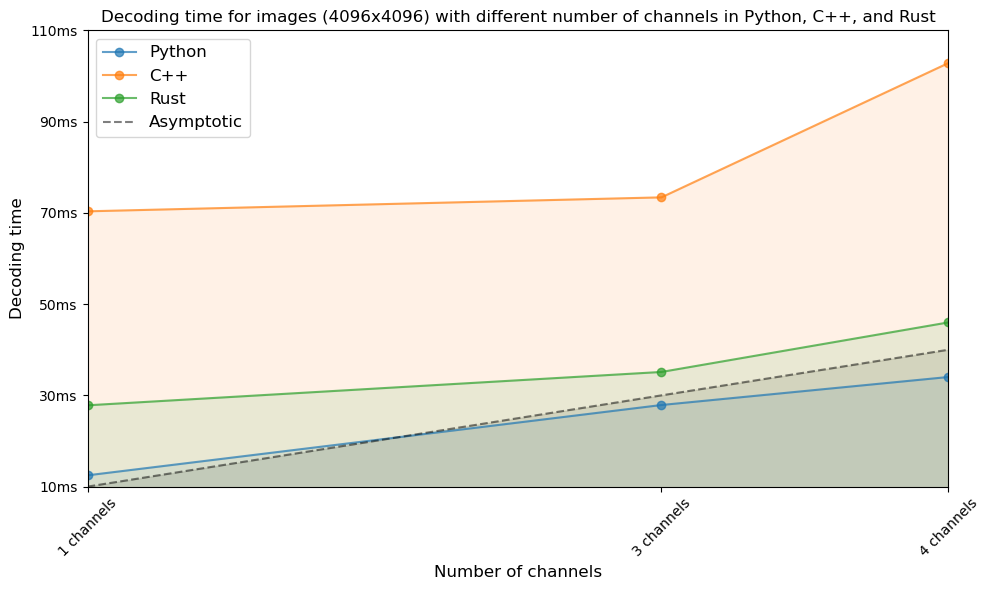

In [125]:
# plot three
plt.figure(figsize=(10, 6))
plt.plot(X, decodeNc['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, decodeNc['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, decodeNc['rust'], label='Rust', marker='o', alpha=0.7)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNc['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNc['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNc['rust'], color=GREEN, alpha=0.1)
plt.ylim(10000, 110000)
plt.xlim(1, 4)
plt.xscale('linear')
plt.yscale('linear')

plt.xticks(X, labels=[f'{x} channels' for x in X], rotation=45)
plt.yticks([10000, 30000, 50000, 70000, 90000, 110000],
           labels=['10ms', '30ms', '50ms', '70ms', '90ms', '110ms'])
plt.xlabel('Number of channels', fontsize=12)
plt.ylabel('Decoding time', fontsize=12)
plt.title('Decoding time for images (4096x4096) with different number of channels in Python, C++, and Rust', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_decodeNc.png'), dpi=300)

plt.show()

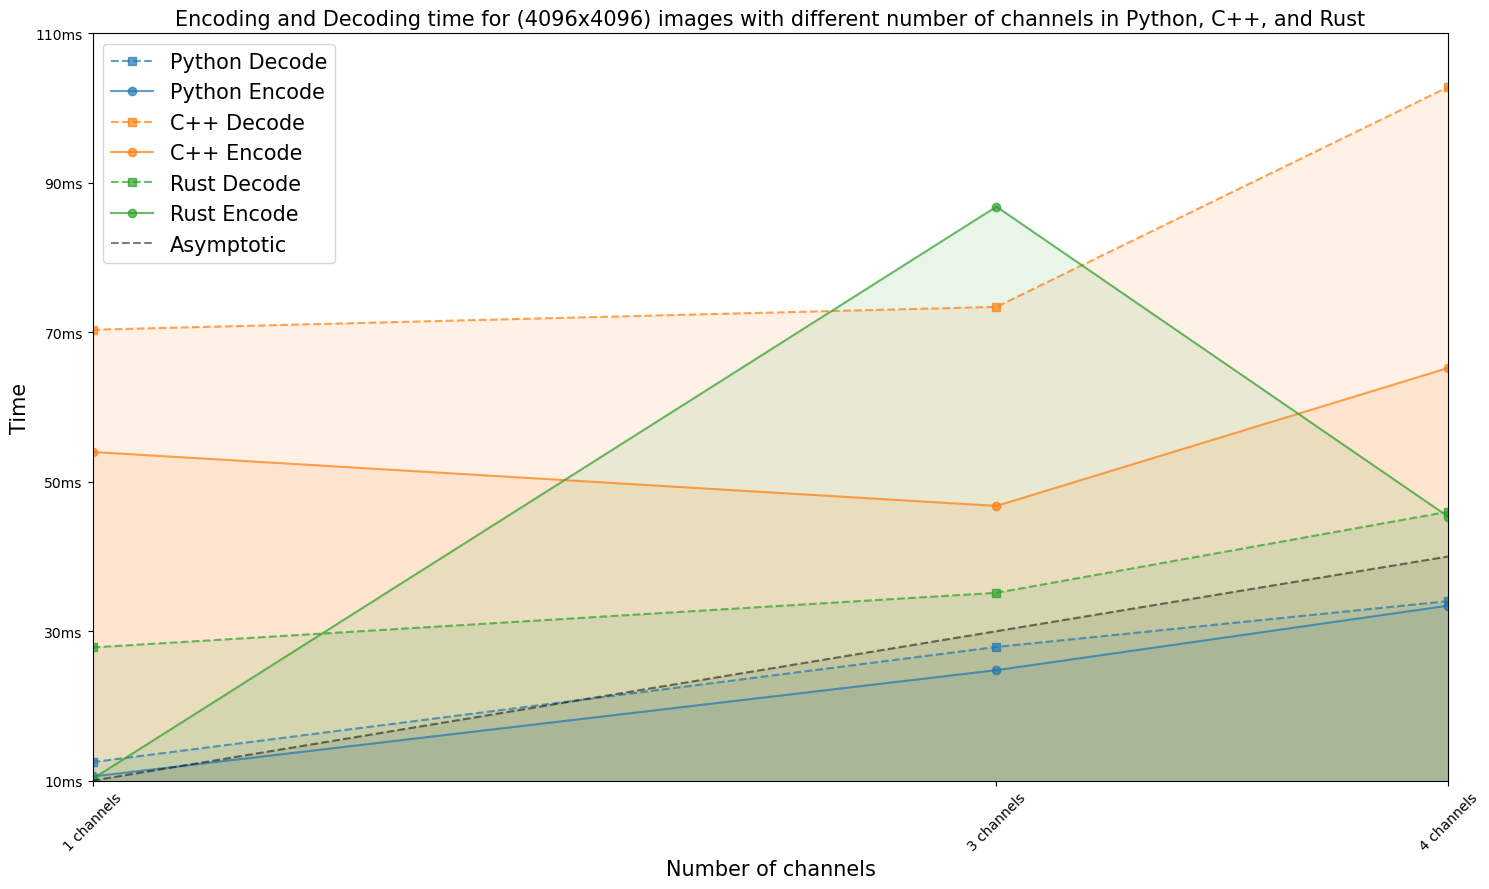

In [126]:
# compare decode & encode
plt.figure(figsize=(15, 9))
plt.plot(X, decodeNc['py'], label='Python Decode', marker='s', alpha=0.7, color=BLUE, linestyle='--')
plt.plot(X, encodeNc['py'], label='Python Encode', marker='o', alpha=0.7, color=BLUE)
plt.plot(X, decodeNc['cpp'], label='C++ Decode', marker='s', alpha=0.7, color=ORANGE, linestyle='--')
plt.plot(X, encodeNc['cpp'], label='C++ Encode', marker='o', alpha=0.7, color=ORANGE)
plt.plot(X, decodeNc['rust'], label='Rust Decode', marker='s', alpha=0.7, color=GREEN, linestyle='--')
plt.plot(X, encodeNc['rust'], label='Rust Encode', marker='o', alpha=0.7, color=GREEN)

plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNc['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNc['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNc['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNc['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNc['rust'], color=GREEN, alpha=0.1)
plt.fill_between(X, 0, encodeNc['rust'], color=GREEN, alpha=0.1)
plt.ylim(10000, 110000)
plt.xlim(1, 4)
plt.xscale('linear')
plt.yscale('linear')
plt.xticks(X, labels=[f'{x} channels' for x in X], rotation=45)
plt.yticks([10000, 30000, 50000, 70000, 90000, 110000],
           labels=['10ms', '30ms', '50ms', '70ms', '90ms', '110ms'])
plt.xlabel('Number of channels', fontsize=15)
plt.ylabel('Time', fontsize=15)
plt.title('Encoding and Decoding time for (4096x4096) images with different number of channels in Python, C++, and Rust', fontsize=15)
plt.legend(loc='upper left', fontsize=15)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encode_decodeNc.png'), dpi=300)

# Show the plot
plt.show()

In [127]:
encodeNxM = {}
encodeNxM['py'] = py_results[20:30]['duration_formatted(us)'].values
encodeNxM['cpp'] = cpp_results[20:30]['real_time'].values * 1e3  # Convert ms to us
encodeNxM['rust'] = rust_results[20:30]['duration_formatted(us)'].values

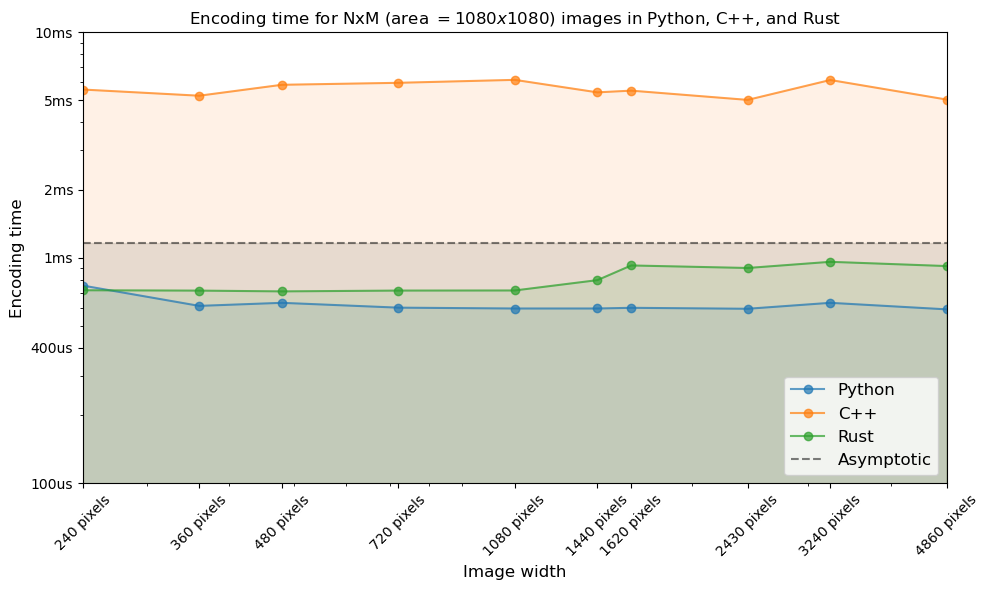

In [128]:

X = np.array([240, 360, 480, 720, 1080, 1440, 1620, 2430, 3240, 4860], dtype=np.int32)
asymptotic = np.repeat([1], len(X)) * 1080 * 1080 / 1000  # Asymptotic for NxM images in ms

# plot three (3D curve)
fig = plt.figure(figsize=(10, 6))
plt.plot(X, encodeNxM['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, encodeNxM['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, encodeNxM['rust'], label='Rust', marker='o', alpha=0.7)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['rust'], color=GREEN, alpha=0.1)
plt.ylim(100, 10000)
plt.xlim(240, 4860)
plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x} pixels' for x in X], rotation=45)
plt.yticks([100, 400, 1000, 2000, 5000, 10000],
           labels=['100us','400us', '1ms', '2ms', '5ms', '10ms'])
plt.xlabel('Image width', fontsize=12)
plt.ylabel('Encoding time', fontsize=12)
plt.title('Encoding time for NxM (area $= 1080 x 1080$) images in Python, C++, and Rust', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encodeNxM.png'), dpi=300)
# Show the plot
plt.show()

In [129]:
decodeNxM = {}
decodeNxM['py'] = py_results[30:40]['duration_formatted(us)'].values
decodeNxM['cpp'] = cpp_results[30:40]['real_time'].values * 1e3  # Convert ms to us
decodeNxM['rust'] = rust_results[30:40]['duration_formatted(us)'].values

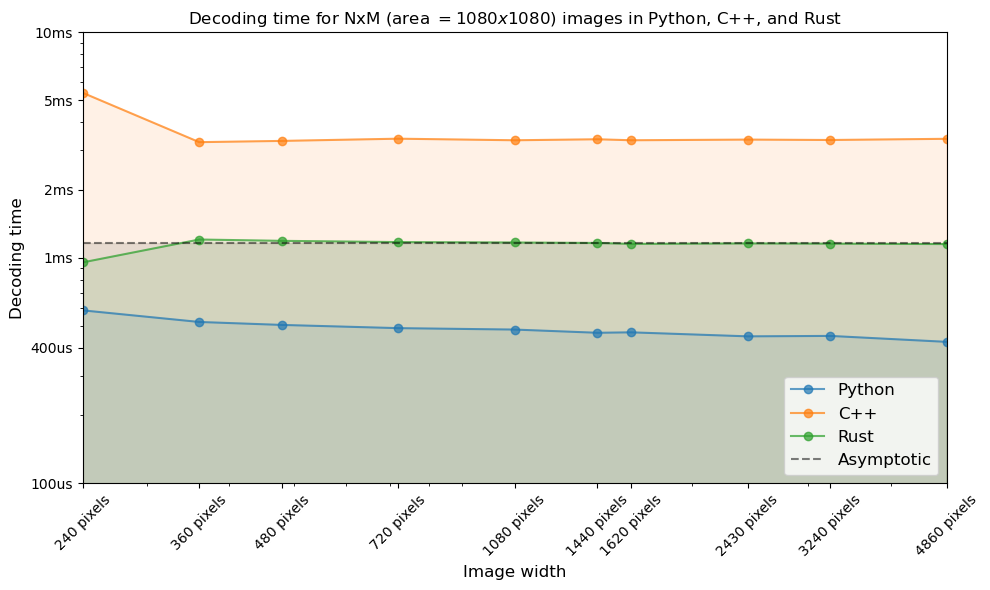

In [130]:
# plot three
plt.figure(figsize=(10, 6))
plt.plot(X, decodeNxM['py'], label='Python', marker='o', alpha=0.7)
plt.plot(X, decodeNxM['cpp'], label='C++', marker='o', alpha=0.7)
plt.plot(X, decodeNxM['rust'], label='Rust', marker='o', alpha=0.7)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['rust'], color=GREEN, alpha=0.1)
plt.ylim(100, 10000)
plt.xlim(240, 4860)
plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x} pixels' for x in X], rotation=45)
plt.yticks([100, 400, 1000, 2000, 5000, 10000],
           labels=['100us','400us', '1ms', '2ms', '5ms', '10ms'])
plt.xlabel('Image width', fontsize=12)
plt.ylabel('Decoding time', fontsize=12)
plt.title('Decoding time for NxM (area $= 1080 x 1080$) images in Python, C++, and Rust', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(osp.join(RESULTS_DIR, 'bench_io_decodeNxM.png'), dpi=300)

plt.show()

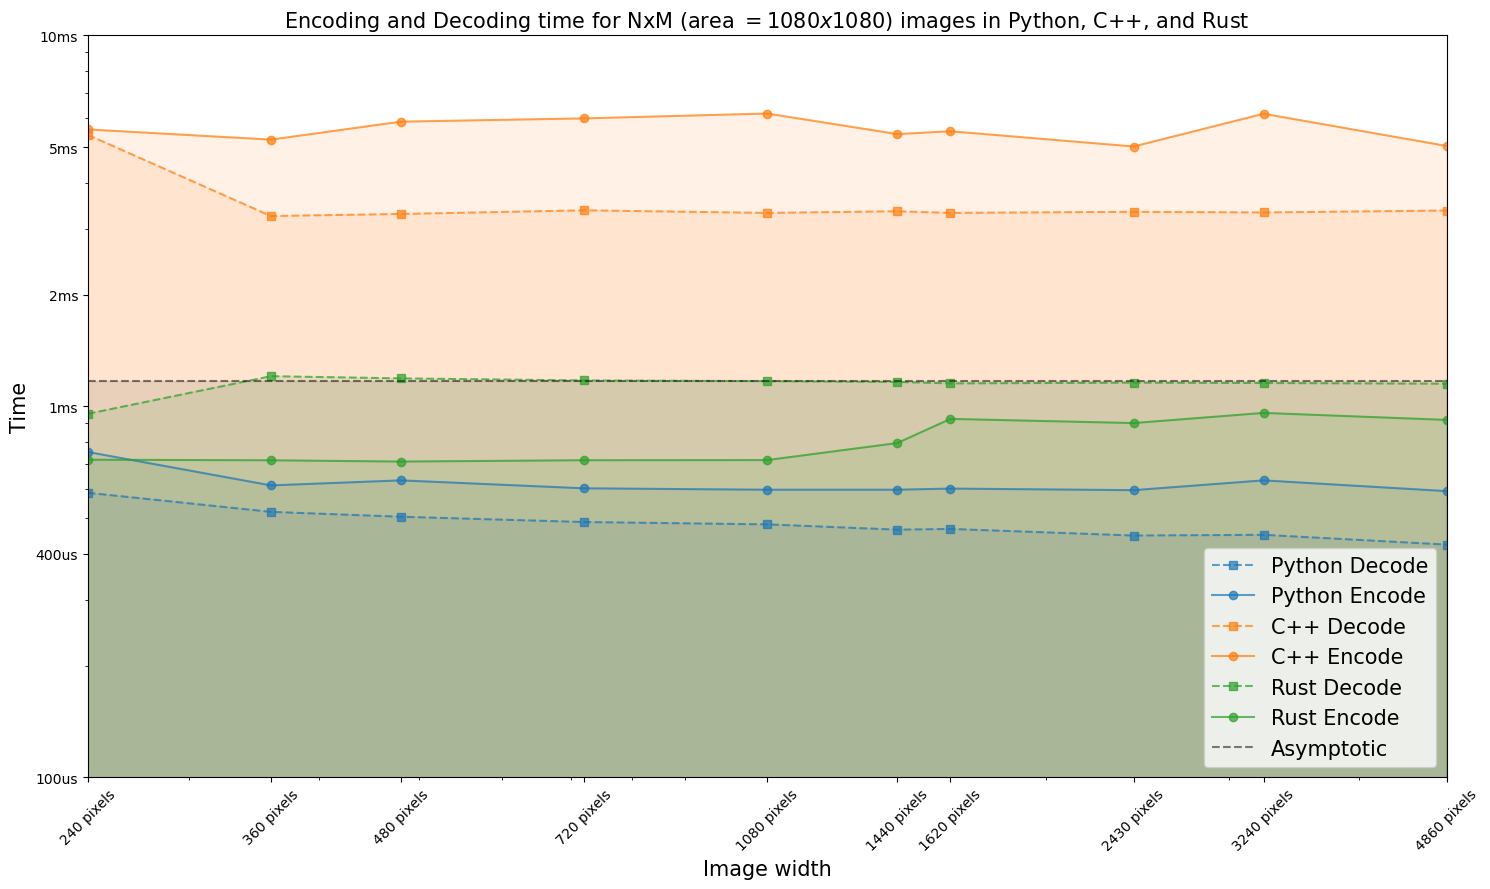

In [131]:
# compare decode & encode
plt.figure(figsize=(15, 9))
plt.plot(X, decodeNxM['py'], label='Python Decode', marker='s', alpha=0.7, color=BLUE, linestyle='--')
plt.plot(X, encodeNxM['py'], label='Python Encode', marker='o', alpha=0.7, color=BLUE)
plt.plot(X, decodeNxM['cpp'], label='C++ Decode', marker='s', alpha=0.7, color=ORANGE, linestyle='--')
plt.plot(X, encodeNxM['cpp'], label='C++ Encode', marker='o', alpha=0.7, color=ORANGE)
plt.plot(X, decodeNxM['rust'], label='Rust Decode', marker='s', alpha=0.7, color=GREEN, linestyle='--')
plt.plot(X, encodeNxM['rust'], label='Rust Encode', marker='o', alpha=0.7, color=GREEN)
plt.plot(X, asymptotic, label='Asymptotic', linestyle='--', color=BLACK, alpha=0.5)
plt.fill_between(X, 0, asymptotic, color=BLACK, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['py'], color=BLUE, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['cpp'], color=ORANGE, alpha=0.1)
plt.fill_between(X, 0, decodeNxM['rust'], color=GREEN, alpha=0.1)
plt.fill_between(X, 0, encodeNxM['rust'], color=GREEN, alpha=0.1)
plt.ylim(100, 10000)
plt.xlim(240, 4860)
plt.xscale('log')
plt.yscale('log')
plt.xticks(X, labels=[f'{x} pixels' for x in X], rotation=45)
plt.yticks([100, 400, 1000, 2000, 5000, 10000],
           labels=['100us','400us', '1ms', '2ms', '5ms', '10ms'])
plt.xlabel('Image width', fontsize=15)
plt.ylabel('Time', fontsize=15)
plt.title('Encoding and Decoding time for NxM (area $= 1080 x 1080$) images in Python, C++, and Rust', fontsize=15)
plt.legend(loc='lower right', fontsize=15)
plt.grid(False)
plt.tight_layout()

plt.savefig(osp.join(RESULTS_DIR, 'bench_io_encode_decodeNxM.png'), dpi=300)
# Show the plot
plt.show()